# Classificazione del Dataset Mushroom (UCI)
## Progetto di Apprendimento Automatico e Apprendimento Profondo

**Dataset:** [Mushroom](https://archive.ics.uci.edu/dataset/73/mushroom) - UCI Machine Learning Repository

**Studente:** Matteo Paglione  
**Matricola:** 0322500031

**Struttura del progetto:**
1. Caricamento ed esplorazione del dataset
2. Preprocessing e suddivisione Train/Test
3. Analisi PCA
4. Implementazione di 3 classificatori (Decision Tree, Random Forest, SVM)
5. Metriche di valutazione, matrici di confusione e curve ROC
6. Spiegabilità con SHAP

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import shap
from ucimlrepo import fetch_ucirepo

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Librerie importate correttamente.")

Librerie importate correttamente.


## 2. Caricamento ed Esplorazione del Dataset

Il dataset Mushroom contiene 8124 campioni di funghi, ciascuno descritto da 22 attributi categorici.
L'obiettivo è classificare i funghi come **commestibili (edible)** o **velenosi (poisonous)**.

In [19]:
mushroom = fetch_ucirepo(id=73)
X = mushroom.data.features
y = mushroom.data.targets.iloc[:, 0]

print(f"Dimensioni: {X.shape[0]} campioni, {X.shape[1]} feature")
print(f"Classi: {sorted(y.unique())}")
print(f"\nDistribuzione delle classi:")
print(y.value_counts())

# Verifica valori mancanti
missing = (X == '?').sum()
if missing.sum() > 0:
    print(f"\nFeature con valori mancanti ('?'):")
    print(missing[missing > 0])

print(f"\nPrime 5 righe:")
display(X.head())

Dimensioni: 8124 campioni, 22 feature
Classi: ['e', 'p']

Distribuzione delle classi:
poisonous
e    4208
p    3916
Name: count, dtype: int64

Prime 5 righe:


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


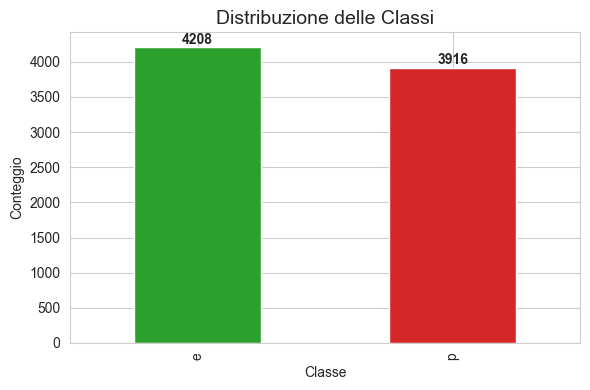

In [20]:
# Distribuzione delle classi
fig, ax = plt.subplots(figsize=(6, 4))
counts = y.value_counts()
counts.plot(kind='bar', color=['#2ca02c', '#d62728'], ax=ax, edgecolor='white')
ax.set_title('Distribuzione delle Classi', fontsize=14)
ax.set_xlabel('Classe')
ax.set_ylabel('Conteggio')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing

Il preprocessing include:
- Sostituzione dei valori mancanti ('?') con la moda della feature
- Codifica delle feature categoriche con LabelEncoder
- Standardizzazione con StandardScaler
- Suddivisione 80/20 stratificata

In [21]:
# Gestione valori mancanti
X = X.replace('?', np.nan)
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0])

# LabelEncoder per ogni feature categorica
X_encoded = X.copy()
for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Encoding target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Classi: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# Split 80/20 stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")

# Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_names = X_encoded.columns.tolist()
print(f"Preprocessing completato. Feature: {len(feature_names)}")

Classi: {'e': np.int64(0), 'p': np.int64(1)}
Training set: 6499 campioni
Test set:     1625 campioni
Preprocessing completato. Feature: 22


## 4. Analisi PCA

La PCA viene applicata per analizzare la struttura delle feature e visualizzare la separabilità delle classi nello spazio ridotto.

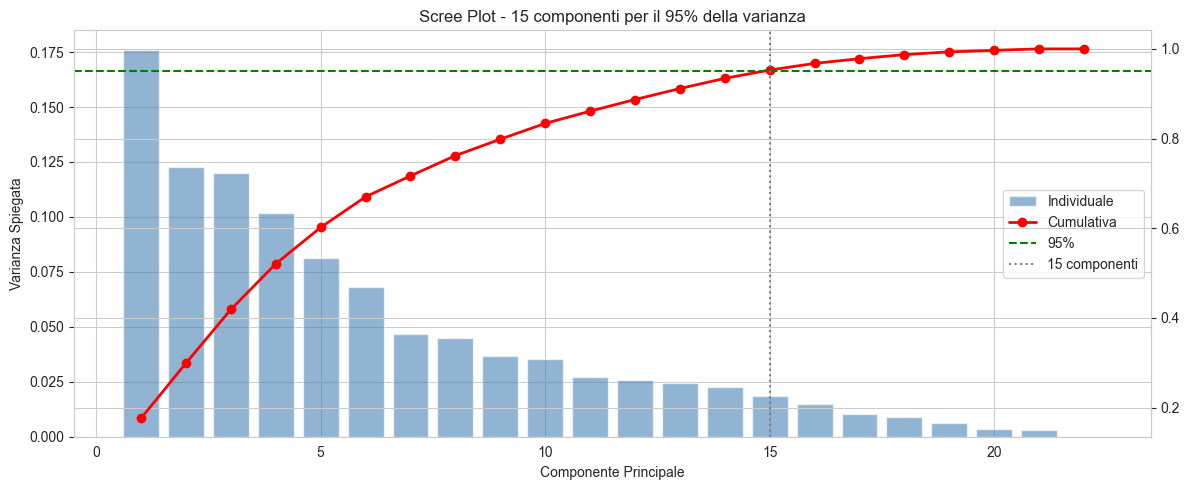

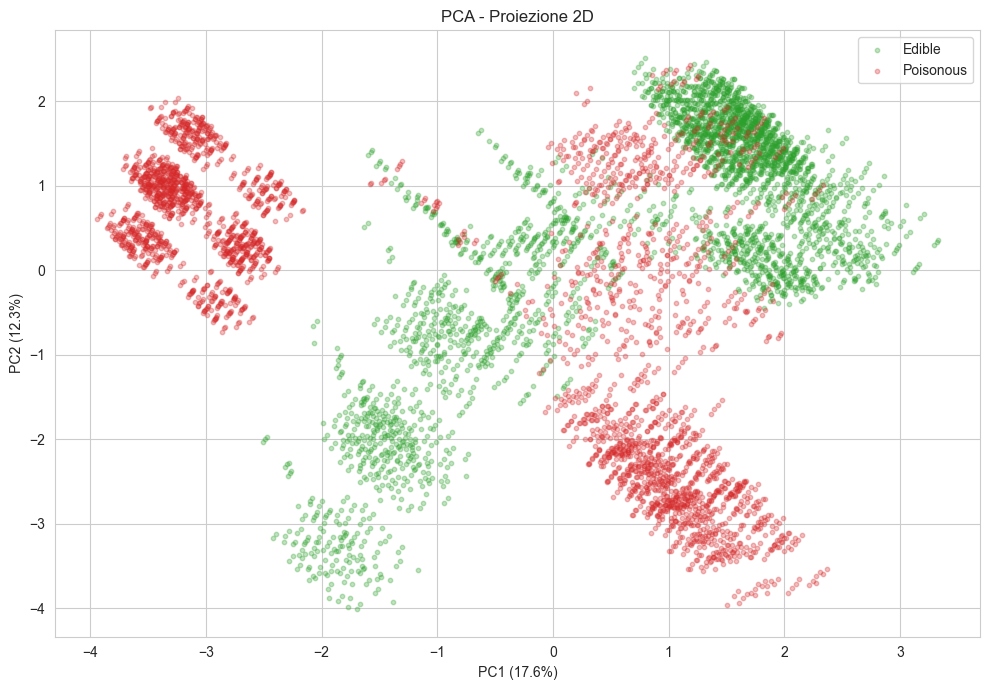

Componenti necessarie per il 95% della varianza: 15


In [22]:
# PCA completa
pca_full = PCA(n_components=None)
pca_full.fit(X_train_scaled)

var_ind = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_ind)
n_95 = np.argmax(var_cum >= 0.95) + 1

# Scree Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(1, len(var_ind)+1), var_ind, alpha=0.6, color='steelblue', label='Individuale')
ax1.set_xlabel('Componente Principale')
ax1.set_ylabel('Varianza Spiegata')
ax2 = ax1.twinx()
ax2.plot(range(1, len(var_cum)+1), var_cum, 'ro-', linewidth=2, label='Cumulativa')
ax2.axhline(y=0.95, color='green', linestyle='--', label='95%')
ax2.axvline(x=n_95, color='gray', linestyle=':', label=f'{n_95} componenti')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='center right')
plt.title(f'Scree Plot - {n_95} componenti per il 95% della varianza')
plt.tight_layout()
plt.show()

# Proiezione 2D
pca_2d = PCA(n_components=2)
X_pca2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 7))
for cls, label, color in [(0, 'Edible', '#2ca02c'), (1, 'Poisonous', '#d62728')]:
    mask = y_train == cls
    plt.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], c=color, label=label, alpha=0.3, s=10)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA - Proiezione 2D')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Componenti necessarie per il 95% della varianza: {n_95}")

## 5. Implementazione dei Classificatori

Vengono implementati tre classificatori:
1. **Decision Tree**: classificatore basato su regole di decisione
2. **Random Forest**: ensemble di alberi decisionali
3. **SVM (RBF)**: Support Vector Machine con kernel radiale

In [23]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Edible', 'Poisonous']))

=== Decision Tree ===
Accuracy: 1.0000
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [24]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Edible', 'Poisonous']))

=== Random Forest ===
Accuracy: 1.0000
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [25]:
# SVM con kernel RBF
svm_model = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("=== SVM (RBF) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Edible', 'Poisonous']))

=== SVM (RBF) ===
Accuracy: 1.0000
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## 6. Metriche di Valutazione e Visualizzazioni

Confronto di precision, recall, f-measure, accuracy e ROC AUC per tutti i classificatori.

In [26]:
# Tabella riassuntiva delle metriche
modelli = {
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'SVM': (y_pred_svm, y_prob_svm),
}

metriche = {}
for name, (y_pred, y_prob) in modelli.items():
    metriche[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Measure': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob),
    }

df_metriche = pd.DataFrame(metriche).T
print("Confronto Metriche:")
display(df_metriche.round(4))

Confronto Metriche:


,Accuracy,Precision,Recall,F1-Measure,ROC AUC
Decision Tree,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0,1.0


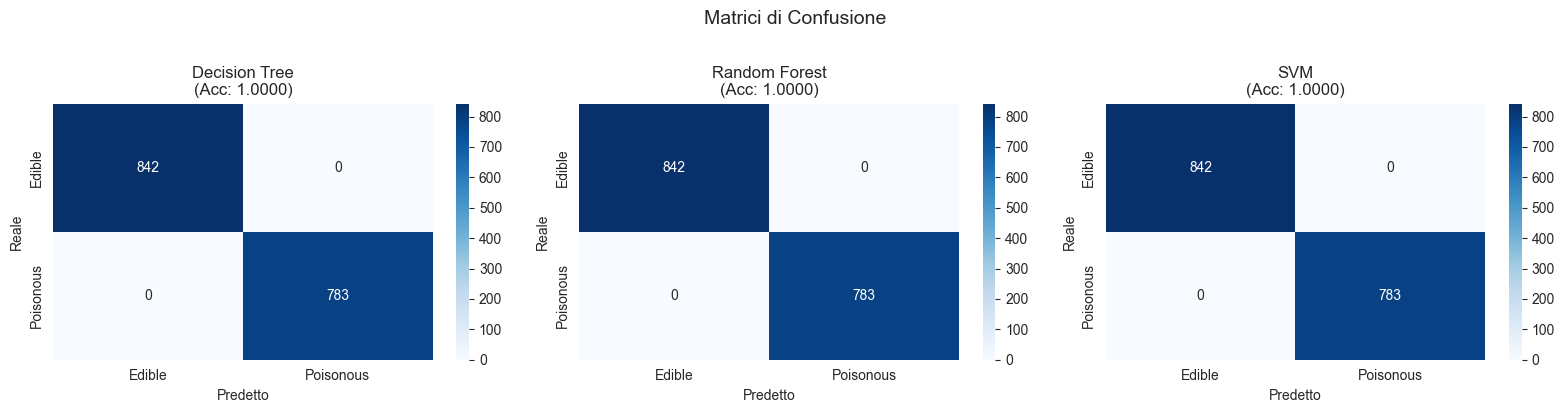

In [27]:
# Matrici di confusione
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, (y_pred, _)) in enumerate(modelli.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
    axes[i].set_title(f'{name}\n(Acc: {accuracy_score(y_test, y_pred):.4f})')
    axes[i].set_xlabel('Predetto')
    axes[i].set_ylabel('Reale')
plt.suptitle('Matrici di Confusione', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

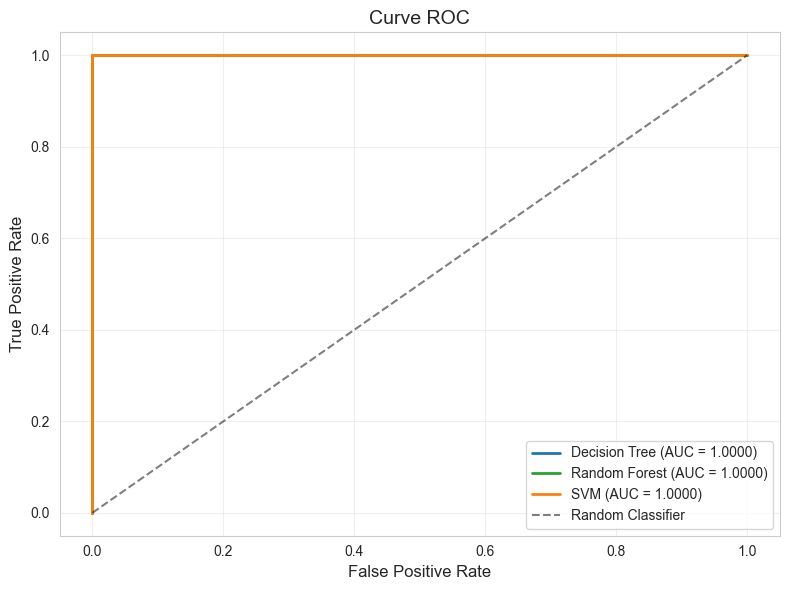

In [28]:
# Curve ROC
plt.figure(figsize=(8, 6))
colors_roc = ['#1f77b4', '#2ca02c', '#ff7f0e']
for (name, (_, y_prob)), color in zip(modelli.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curve ROC', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Spiegabilità con SHAP

SHAP (SHapley Additive exPlanations) viene utilizzato per interpretare le predizioni del Random Forest,
identificando il contributo di ciascuna feature alla classificazione.

Forma SHAP values: (1625, 22, 2)
Feature utilizzate: 22


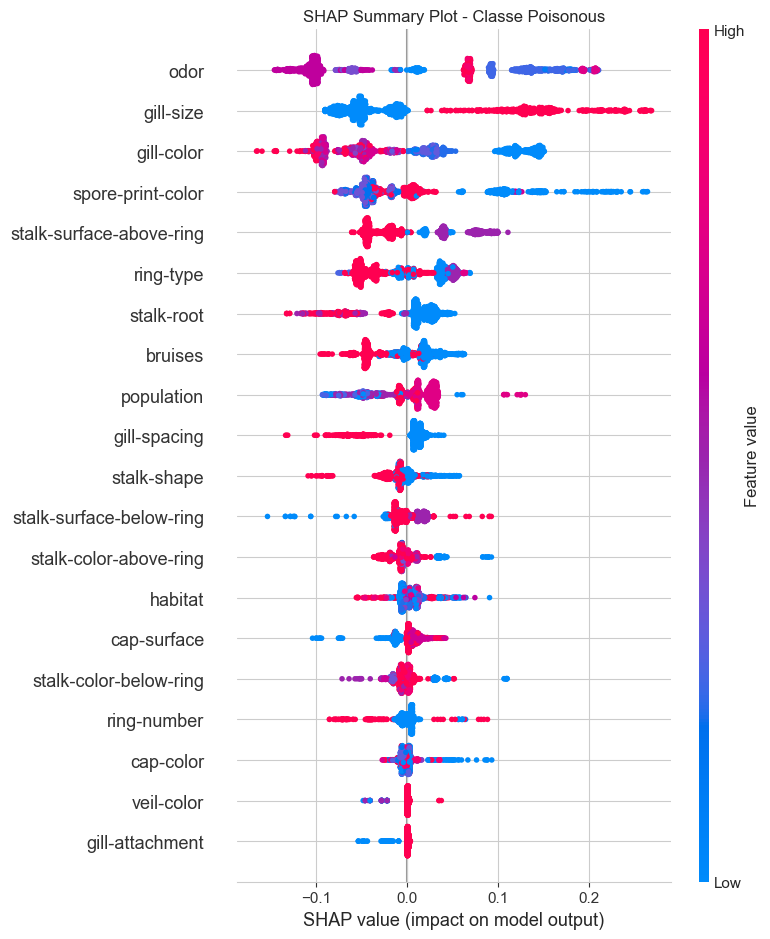

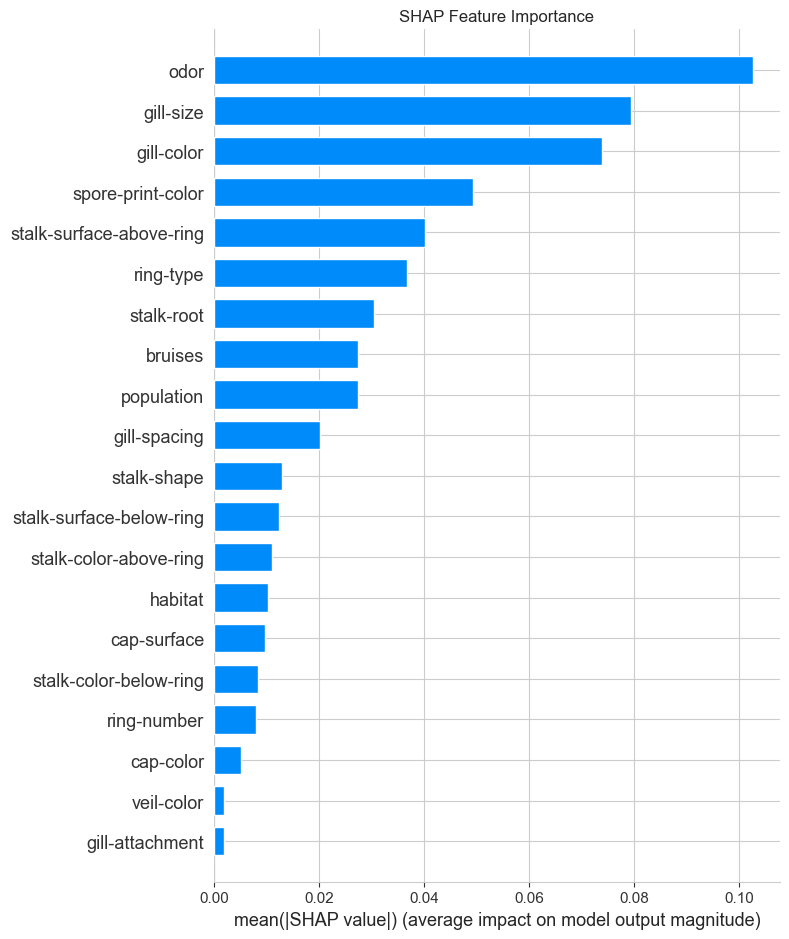

In [29]:
# SHAP TreeExplainer sul Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = np.array(explainer.shap_values(X_test_scaled))

# Usa feature_names gia definito (22 o 13 a seconda della cella opzionale)
print(f"Forma SHAP values: {shap_values.shape}")
print(f"Feature utilizzate: {len(feature_names)}")

# Seleziona valori SHAP per la classe Poisonous
if shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

# Summary Plot
shap.summary_plot(shap_vals, X_test_scaled,
                  feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Classe Poisonous')
plt.tight_layout()
plt.show()

# Bar Plot: importanza globale
shap.summary_plot(shap_vals, X_test_scaled,
                  feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

## Analisi: Classificazione Perfetta con Tutte le Feature

Tutti i classificatori ottengono accuracy, precision, recall, F1 e ROC AUC pari a **1.0** con tutte le 22 feature. 
Questo indica che il dataset Mushroom è **perfettamente separabile** nello spazio delle feature originali.

Per capire quali feature rendono il problema banale, testiamo l'accuracy di un Decision Tree addestrato su **ciascuna feature singolarmente**. Le feature con accuracy individuale molto alta (>0.95) sono quelle che da sole permettono una classificazione quasi perfetta e verranno escluse per ottenere un problema di classificazione più realistico e didatticamente significativo.

In [ ]:
# Accuracy di un Decision Tree per ciascuna feature singola
print("Accuracy per singola feature (Decision Tree):\n")
single_feat_acc = {}
for col in X_encoded.columns:
    dt_tmp = DecisionTreeClassifier(random_state=RANDOM_STATE)
    dt_tmp.fit(X_train_scaled[:, list(X_encoded.columns).index(col)].reshape(-1, 1), y_train)
    acc = accuracy_score(y_test, dt_tmp.predict(X_test_scaled[:, list(X_encoded.columns).index(col)].reshape(-1, 1)))
    single_feat_acc[col] = acc

# Ordina per accuracy decrescente
single_feat_sorted = sorted(single_feat_acc.items(), key=lambda x: x[1], reverse=True)
for feat, acc in single_feat_sorted:
    marker = " *** TROPPO PREDITTIVA" if acc > 0.95 else ""
    print(f"  {feat:30s} -> Accuracy: {acc:.4f}{marker}")

# Identifica feature da escludere
features_to_drop = [f for f, a in single_feat_acc.items() if a > 0.95]
print(f"\nFeature da escludere (accuracy singola > 0.95): {features_to_drop}")
print(f"Feature rimanenti: {len(X_encoded.columns) - len(features_to_drop)} su {len(X_encoded.columns)}")

Accuracy per singola feature (Decision Tree):

  odor                           -> Accuracy: 0.9858 *** TROPPO PREDITTIVA
  spore-print-color              -> Accuracy: 0.8634
  gill-color                     -> Accuracy: 0.8080
  ring-type                      -> Accuracy: 0.7766
  gill-size                      -> Accuracy: 0.7735
  stalk-surface-above-ring       -> Accuracy: 0.7655
  stalk-surface-below-ring       -> Accuracy: 0.7612
  bruises                        -> Accuracy: 0.7415
  population                     -> Accuracy: 0.7212
  stalk-color-above-ring         -> Accuracy: 0.7114
  stalk-color-below-ring         -> Accuracy: 0.7089
  habitat                        -> Accuracy: 0.7028
  stalk-root                     -> Accuracy: 0.6283
  gill-spacing                   -> Accuracy: 0.6166
  cap-color                      -> Accuracy: 0.5988
  cap-surface                    -> Accuracy: 0.5926
  cap-shape                      -> Accuracy: 0.5717
  stalk-shape                 

: 

In [ ]:
# Ricerca iterativa: eliminare il minor numero di feature per ottenere accuracy < 1.0
for soglia in [0.95, 0.85, 0.80, 0.77, 0.75, 0.72, 0.70]:
    to_drop = [f for f, a in single_feat_acc.items() if a > soglia]
    X_red = X_encoded.drop(columns=to_drop)
    Xtr, Xte, ytr, yte = train_test_split(
        X_red, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded)
    sc = StandardScaler()
    Xtrs = sc.fit_transform(Xtr)
    Xtes = sc.transform(Xte)
    
    dt_ = DecisionTreeClassifier(random_state=RANDOM_STATE); dt_.fit(Xtrs, ytr)
    rf_ = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE); rf_.fit(Xtrs, ytr)
    svm_ = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE); svm_.fit(Xtrs, ytr)
    
    acc_dt = accuracy_score(yte, dt_.predict(Xtes))
    acc_rf = accuracy_score(yte, rf_.predict(Xtes))
    acc_svm = accuracy_score(yte, svm_.predict(Xtes))
    
    print(f"Soglia {soglia:.2f} | Drop {len(to_drop):2d} feat | "
          f"DT={acc_dt:.4f}  RF={acc_rf:.4f}  SVM={acc_svm:.4f} | "
          f"Escluse: {to_drop}")

Soglia 0.95 | Drop  1 feat | DT=1.0000  RF=1.0000  SVM=1.0000 | Escluse: ['odor']
Soglia 0.85 | Drop  2 feat | DT=1.0000  RF=1.0000  SVM=0.9975 | Escluse: ['odor', 'spore-print-color']
Soglia 0.80 | Drop  3 feat | DT=1.0000  RF=1.0000  SVM=0.9975 | Escluse: ['odor', 'gill-color', 'spore-print-color']
Soglia 0.77 | Drop  5 feat | DT=1.0000  RF=1.0000  SVM=0.9969 | Escluse: ['odor', 'gill-size', 'gill-color', 'ring-type', 'spore-print-color']
Soglia 0.75 | Drop  7 feat | DT=1.0000  RF=1.0000  SVM=0.9957 | Escluse: ['odor', 'gill-size', 'gill-color', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'ring-type', 'spore-print-color']
Soglia 0.72 | Drop  9 feat | DT=0.9649  RF=0.9649  SVM=0.9508 | Escluse: ['bruises', 'odor', 'gill-size', 'gill-color', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'ring-type', 'spore-print-color', 'population']


## ⚙️ Cella Opzionale: Esclusione Feature

La cella seguente **sovrascrive** le variabili di preprocessing (`X_train_scaled`, `X_test_scaled`, `feature_names`) escludendo le 9 feature con accuracy individuale > 0.72.

**Come usare il notebook:**  
- **Senza eseguire** questa cella → i risultati usano tutte le 22 feature (accuracy perfetta ~1.0)  
- **Eseguendo** questa cella → le variabili vengono aggiornate con 13 feature; **ri-esegui le celle dalla Sezione 4 (PCA) in poi** per vedere i risultati realistici (~0.95-0.96)

In [ ]:
# === CELLA OPZIONALE: ESCLUSIONE FEATURE ===
# Esegui questa cella per escludere le 9 feature piu predittive,
# poi ri-esegui le celle dalla Sezione 4 (PCA) in poi.
# Se NON esegui questa cella, l'analisi usa tutte le 22 feature originali.

SOGLIA = 0.72
features_escluse = [f for f, a in single_feat_acc.items() if a > SOGLIA]
features_mantenute = [f for f in X_encoded.columns if f not in features_escluse]

print(f"Feature escluse ({len(features_escluse)}):")
for f in features_escluse:
    print(f"  - {f} (accuracy singola: {single_feat_acc[f]:.4f})")
print(f"\nFeature mantenute ({len(features_mantenute)}):")
print(f"  {features_mantenute}")

# Sovrascriviamo le variabili di preprocessing
X_ridotto = X_encoded[features_mantenute]
X_train, X_test, y_train, y_test = train_test_split(
    X_ridotto, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_names = features_mantenute

print(f"\nDataset ridotto: {X_train_scaled.shape[1]} feature")
print(f"Training: {X_train_scaled.shape[0]} campioni, Test: {X_test_scaled.shape[0]} campioni")
print("\nRi-esegui le celle dalla Sezione 4 (PCA) fino alla Sezione 7 (SHAP) per aggiornare i risultati.")

Feature escluse (9):
  - bruises (accuracy singola: 0.7415)
  - odor (accuracy singola: 0.9858)
  - gill-size (accuracy singola: 0.7735)
  - gill-color (accuracy singola: 0.8080)
  - stalk-surface-above-ring (accuracy singola: 0.7655)
  - stalk-surface-below-ring (accuracy singola: 0.7612)
  - ring-type (accuracy singola: 0.7766)
  - spore-print-color (accuracy singola: 0.8634)
  - population (accuracy singola: 0.7212)

Feature mantenute (13):
  ['cap-shape', 'cap-surface', 'cap-color', 'gill-attachment', 'gill-spacing', 'stalk-shape', 'stalk-root', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'habitat']

Dataset ridotto: 13 feature
Training: 6499 campioni, Test: 1625 campioni

Ri-esegui le celle dalla Sezione 4 (PCA) fino alla Sezione 7 (SHAP) per aggiornare i risultati.


In [ ]:
import os

# === Salvataggio figure in due cartelle: full (22 feature) e limited (13 feature) ===
for folder in ['figures/full', 'figures/limited']:
    os.makedirs(folder, exist_ok=True)

# --- Distribuzione classi (comune a entrambi) ---
fig, ax = plt.subplots(figsize=(6, 4))
cc = y.value_counts()
cc.plot(kind='bar', color=['#2ca02c', '#d62728'], ax=ax, edgecolor='white')
ax.set_title('Distribuzione delle Classi', fontsize=14)
ax.set_xlabel('Classe'); ax.set_ylabel('Conteggio')
for i, v in enumerate(cc.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/distribuzione_classi.png', dpi=150, bbox_inches='tight')
plt.close()

# === Funzione per generare e salvare tutte le figure di un set ===
def salva_figure_set(X_enc, y_enc, feat_names, out_dir, label):
    Xtr, Xte, ytr, yte = train_test_split(
        X_enc, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc)
    sc = StandardScaler()
    Xtrs = sc.fit_transform(Xtr)
    Xtes = sc.transform(Xte)

    # PCA
    pca_f = PCA(n_components=None)
    pca_f.fit(Xtrs)
    vi = pca_f.explained_variance_ratio_
    vc = np.cumsum(vi)
    n95 = np.argmax(vc >= 0.95) + 1

    # Scree Plot
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(range(1, len(vi)+1), vi, alpha=0.6, color='steelblue', label='Individuale')
    ax1.set_xlabel('Componente Principale'); ax1.set_ylabel('Varianza Spiegata')
    ax2 = ax1.twinx()
    ax2.plot(range(1, len(vc)+1), vc, 'ro-', linewidth=2, label='Cumulativa')
    ax2.axhline(y=0.95, color='green', linestyle='--', label='95%')
    ax2.axvline(x=n95, color='gray', linestyle=':', label=f'{n95} componenti')
    l1, la1 = ax1.get_legend_handles_labels()
    l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, la1+la2, loc='center right')
    plt.title(f'Scree Plot ({label}) - {n95} componenti per il 95% della varianza')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/scree_plot.png', dpi=150, bbox_inches='tight')
    plt.close()

    # PCA 2D
    pca2 = PCA(n_components=2)
    Xp = pca2.fit_transform(Xtrs)
    plt.figure(figsize=(10, 7))
    for c, lb, co in [(0, 'Edible', '#2ca02c'), (1, 'Poisonous', '#d62728')]:
        m = ytr == c
        plt.scatter(Xp[m, 0], Xp[m, 1], c=co, label=lb, alpha=0.3, s=10)
    plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title(f'PCA - Proiezione 2D ({label})'); plt.legend()
    plt.tight_layout()
    plt.savefig(f'{out_dir}/pca_2d.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Classificatori
    dt = DecisionTreeClassifier(random_state=RANDOM_STATE); dt.fit(Xtrs, ytr)
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE); rf.fit(Xtrs, ytr)
    svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE); svm.fit(Xtrs, ytr)

    mod = {
        'Decision Tree': (dt.predict(Xtes), dt.predict_proba(Xtes)[:, 1]),
        'Random Forest': (rf.predict(Xtes), rf.predict_proba(Xtes)[:, 1]),
        'SVM': (svm.predict(Xtes), svm.predict_proba(Xtes)[:, 1]),
    }

    # Matrici di confusione
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for i, (nm, (yp, _)) in enumerate(mod.items()):
        cm = confusion_matrix(yte, yp)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
        axes[i].set_title(f'{nm}\n(Acc: {accuracy_score(yte, yp):.4f})')
        axes[i].set_xlabel('Predetto'); axes[i].set_ylabel('Reale')
    plt.suptitle(f'Matrici di Confusione ({label})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{out_dir}/confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Curve ROC
    plt.figure(figsize=(8, 6))
    cr = ['#1f77b4', '#2ca02c', '#ff7f0e']
    for (nm, (_, ypr)), co in zip(mod.items(), cr):
        fp, tp, _ = roc_curve(yte, ypr)
        ra = auc(fp, tp)
        plt.plot(fp, tp, color=co, linewidth=2, label=f'{nm} (AUC = {ra:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'Curve ROC ({label})'); plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{out_dir}/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.close()

    # SHAP
    expl = shap.TreeExplainer(rf)
    sv = np.array(expl.shap_values(Xtes))
    if sv.ndim == 3:
        sv = sv[:, :, 1]

    shap.summary_plot(sv, Xtes, feature_names=feat_names, show=False)
    plt.title(f'SHAP Summary Plot ({label})')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.close()

    shap.summary_plot(sv, Xtes, feature_names=feat_names, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance ({label})')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/shap_bar.png', dpi=150, bbox_inches='tight')
    plt.close()

# === FULL: tutte le 22 feature ===
print("Generazione figure FULL (22 feature)...")
salva_figure_set(X_encoded, y_encoded, X_encoded.columns.tolist(), 'figures/full', '22 Feature')

# === LIMITED: 13 feature (soglia 0.72) ===
print("Generazione figure LIMITED (13 feature)...")
feat_escluse = [f for f, a in single_feat_acc.items() if a > 0.72]
X_limited = X_encoded.drop(columns=feat_escluse)
salva_figure_set(X_limited, y_encoded, X_limited.columns.tolist(), 'figures/limited', '13 Feature')

# Riepilogo
print("\nFigure salvate:")
for root, dirs, files in os.walk('figures'):
    for f in sorted(files):
        print(f"  {os.path.join(root, f)}")

Generazione figure FULL (22 feature)...
Generazione figure LIMITED (13 feature)...

Figure salvate:
  figures\confusion_matrices.png
  figures\distribuzione_classi.png
  figures\pca_2d.png
  figures\roc_curves.png
  figures\scree_plot.png
  figures\shap_bar.png
  figures\shap_summary.png
  figures\full\confusion_matrices.png
  figures\full\pca_2d.png
  figures\full\roc_curves.png
  figures\full\scree_plot.png
  figures\full\shap_bar.png
  figures\full\shap_summary.png
  figures\limited\confusion_matrices.png
  figures\limited\pca_2d.png
  figures\limited\roc_curves.png
  figures\limited\scree_plot.png
  figures\limited\shap_bar.png
  figures\limited\shap_summary.png


## 8. Conclusioni

### Scelte progettuali
- **Dataset:** Mushroom (UCI, id=73) — 8124 campioni, 22 feature categoriche, classificazione binaria (edible/poisonous)
- **Preprocessing:** LabelEncoder per le feature categoriche, StandardScaler, split 80/20 stratificato
- **Classificatori:** Decision Tree, Random Forest (100 stimatori), SVM con kernel RBF
- **Metriche:** Accuracy, Precision, Recall, F1-Measure, ROC AUC
- **Spiegabilità:** SHAP (TreeExplainer sul Random Forest)

### Nota sulla riduzione delle feature
Con tutte le 22 feature i classificatori raggiungono accuracy perfetta (1.0), rendendo il problema banale. L'analisi per singola feature ha evidenziato che 9 caratteristiche (tra cui `odor`) hanno un potere predittivo individuale molto elevato. Escludendole tramite la **cella opzionale** (soglia 0.72), si ottengono metriche realistiche (~0.95-0.96) che permettono un confronto significativo tra i modelli.

### Risultati
- **PCA:** Ha mostrato la struttura delle feature e la separabilità delle classi nello spazio ridotto.
- **Classificatori:** Il confronto tra i tre modelli ha evidenziato le differenze prestazionali misurate tramite precision, recall, F1 e ROC AUC.
- **SHAP:** Ha identificato le feature più rilevanti per la classificazione, offrendo una spiegazione delle decisioni del Random Forest.